# **Step 2: Exploratory Data Analysis**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [2]:
# Load Curated Dataset
raw_df = pd.read_csv("ESG_Data.csv", parse_dates=["Date"])

raw_df["YearMonth"] = raw_df["Date"].dt.to_period("M").dt.to_timestamp()

df = (
    raw_df.groupby(["YearMonth", "Emission_Type"])["Emissions_tCO2e"]
    .sum()
    .reset_index()
    .pivot(index="YearMonth",
           columns="Emission_Type",
           values="Emissions_tCO2e")
    .reset_index()
)


In [3]:
df.head()

Emission_Type,YearMonth,Scope 1,Scope 2
0,2020-01-01,1755.795813,1908.584310
1,2020-02-01,1679.152641,1792.904592
2,2020-03-01,1871.382396,1920.870573
3,2020-04-01,1887.235869,1870.897161
4,2020-05-01,1999.483530,1913.012361


# Historical Emissions Trends

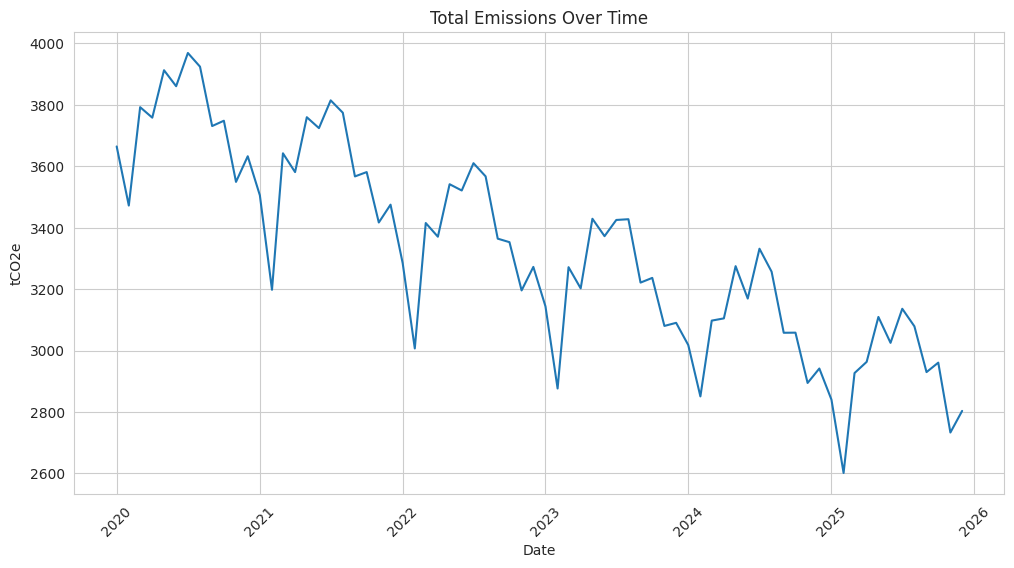

In [6]:
# Total Emissions Over Time
df["Total_Emissions"] = df["Scope 1"] + df["Scope 2"]

plt.figure(figsize=(12,6))
plt.plot(df["YearMonth"], df["Total_Emissions"])
plt.title("Total Emissions Over Time")
plt.xlabel("Date")
plt.ylabel("tCO2e")
plt.xticks(rotation=45)
#plt.savefig("Total_Emissions_Over_Time.svg", format='svg', bbox_inches='tight')
plt.savefig("Total_Emissions_Over_Time.png", dpi=300, bbox_inches='tight')
plt.show()


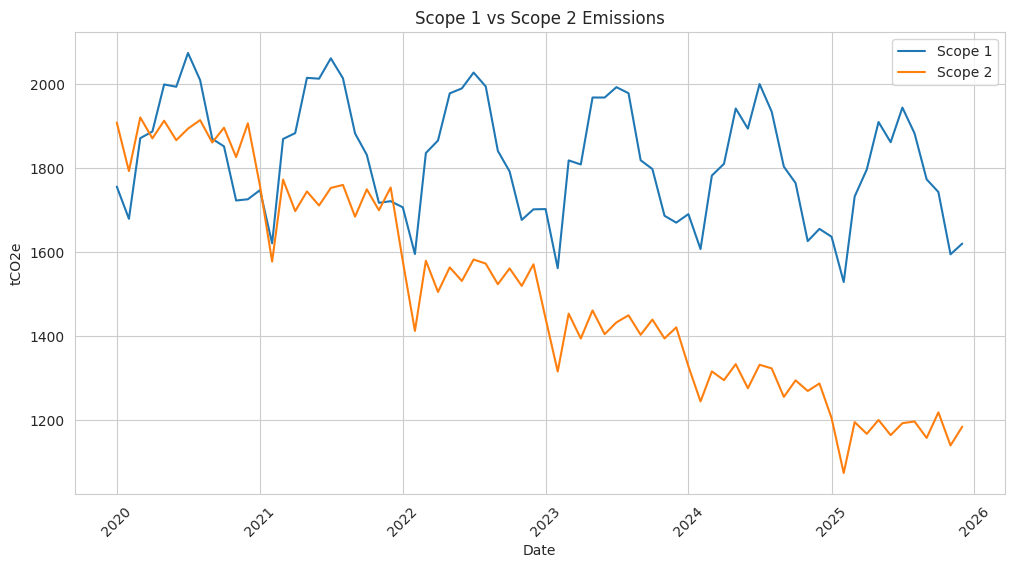

In [8]:
# Scope 1 vs Scope 2 Comparison
plt.figure(figsize=(12,6))
plt.plot(df["YearMonth"], df["Scope 1"], label="Scope 1")
plt.plot(df["YearMonth"], df["Scope 2"], label="Scope 2")

plt.title("Scope 1 vs Scope 2 Emissions")
plt.legend()
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("tCO2e")
plt.savefig('Scope1_vs_scope2_emissions.svg', format='svg', bbox_inches='tight')
plt.savefig('Scope1_vs_scope2_emissions.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
%pip install -U kaleido


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 1.4 MB/s eta 0:00:008.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.4/152.4 kB 3.8 MB/s eta 0:00:005.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


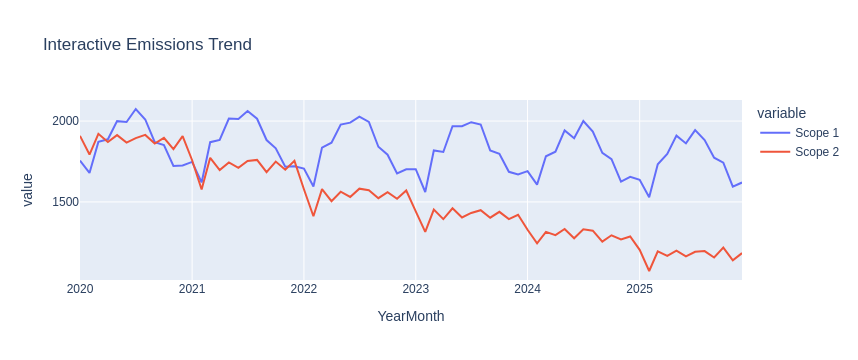

In [14]:
# Interactive Trend
fig = px.line(
    df,
    x="YearMonth",
    y=["Scope 1", "Scope 2"],
    title="Interactive Emissions Trend"
)
#fig.write_image("Interactive_emissions_trend.png", width=1200, height=800, scale=2)
#fig.write_image("Interactive_emissions_trend.svg")
#fig.write_html("Interactive_emissions_report.html")
fig.show()


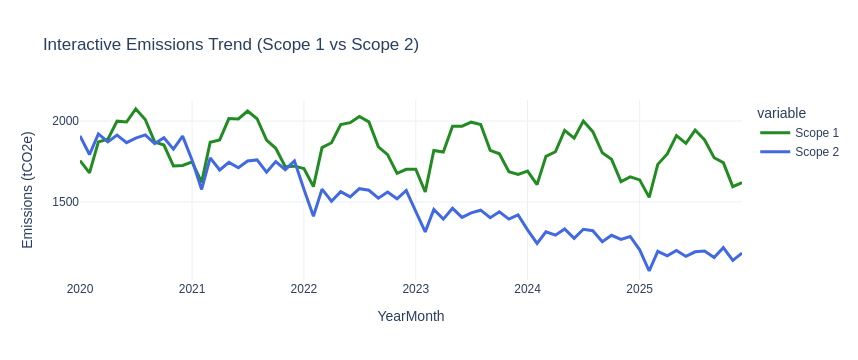

In [15]:
# 1. Define standard environmental colours
# Forest Green for Scope 1 (Direct), Royal Blue for Scope 2 (Energy)
color_map = {
    "Scope 1": "#228B22", 
    "Scope 2": "#4169E1"
}

# 2. Create the plot with the custom map
fig = px.line(
    df,
    x="YearMonth",
    y=["Scope 1", "Scope 2"],
    title="Interactive Emissions Trend (Scope 1 vs Scope 2)",
    color_discrete_map=color_map, # This forces the specific colours
    template="plotly_white"       # Clean background for reports
)

# 3. Enhance the style (Optional but recommended)
fig.update_traces(line=dict(width=3)) # Make lines thicker for visibility
fig.update_layout(
    yaxis_title="Emissions (tCO2e)",
    hovermode="x unified"             # Shows both values on one hover label
)

# 4. Save and Show
#fig.write_image("scope_comparison.svg")
fig.show()

# **Seasonality Analysis**

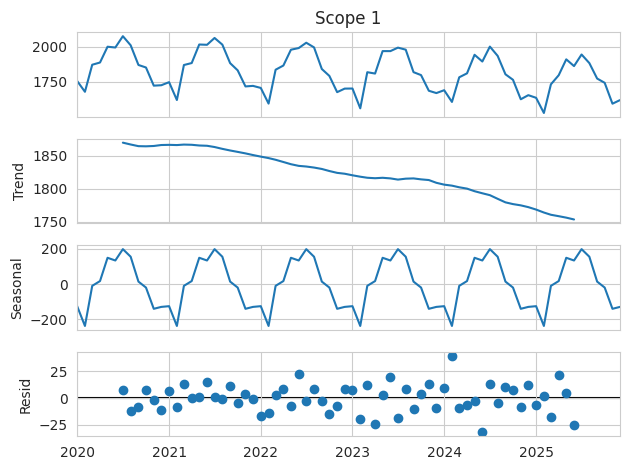

In [16]:
# Decompose Scope 1
scope1_series = df.set_index("YearMonth")["Scope 1"].dropna()

decomposition = seasonal_decompose(scope1_series, model="additive", period=12)

decomposition.plot()
plt.show()


1. Line-by-Line Breakdown
scope1_series = df.set_index("YearMonth")["Scope 1"].dropna()

    set_index("YearMonth"): Moves the time column to the index. Most time-series tools require the index to be the "time axis."
    ["Scope 1"]: Isolates just your Scope 1 emissions for analysis.
    .dropna(): Removes any missing values. Decomposition math fails if there are "holes" in the timeline.

decomposition = seasonal_decompose(..., model="additive", period=12)
This is the "engine" from the statsmodels library.

    model="additive": Assumes that your total emissions are simply the sum of: Trend + Seasonality + Noise. (This is standard for carbon data).
    period=12: Tells Python your data repeats in a yearly cycle. Since your index is "Months," 12 months = 1 full cycle.

2. What the plot() shows you
When you run decomposition.plot(), you get four separate graphs in a stack:

    Observed: Your raw, messy Scope 1 data (the "actuals").

   
    Trend: The "big picture." It removes the monthly zig-zags to show if your emissions are fundamentally increasing or decreasing over the long term.

   
    Seasonal: The "heartbeat" of your data. It shows the patterns that repeat every year (e.g., "Emissions always spike in January due to heating").

   
    Resid (Residual): The "leftovers." This shows weird, one-off spikes or drops that aren't part of the trend or the season (e.g., a massive gas leak or a temporary factory shutdown).

4. Why this is useful for Carbon Analysis

    Predicting the Future: If you know your "Seasonal" spike happens in December, you can prepare your energy budget in advance.
    Checking Success: If your Trend line is pointing down, your sustainability strategy is working—even if the Observed line occasionally spikes due to cold weather.
    Detecting Anomalies: Large spikes in the Resid graph act as an alarm, showing you exactly when something unusual happened that requires an investigation.

5. A Small Tip
If your YearMonth column is still a Period object (from our previous .to_period("M") step), seasonal_decompose might throw an error. If it does, convert the index to a timestamp first:


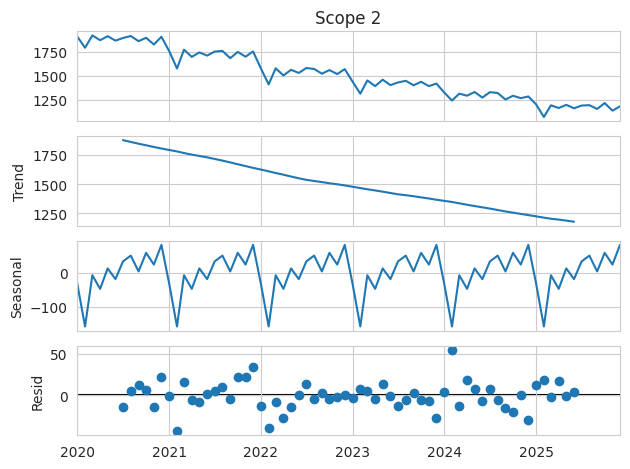

In [17]:
# Decompose Scope 2
scope2_series = df.set_index("YearMonth")["Scope 2"].dropna()

decomposition2 = seasonal_decompose(scope2_series, model="additive", period=12)

decomposition2.plot()
plt.show()


In [19]:
# 1. Extract the trend component for scope 1
trend_series = decomposition.trend.dropna()

# 2. Calculate the total change in the trend
first_trend_val = trend_series.iloc[0]
last_trend_val = trend_series.iloc[-1]
total_trend_change = last_trend_val - first_trend_val

# 3. Calculate average monthly change
# len(trend_series) - 1 gives us the number of months passed
avg_monthly_change = total_trend_change / (len(trend_series) - 1)

print(f"Starting Trend Value: {first_trend_val:.2f} tCO2e")
print(f"Current Trend Value: {last_trend_val:.2f} tCO2e")
print(f"Average Monthly Change: {avg_monthly_change:.2f} tCO2e per month")

Starting Trend Value: 1869.76 tCO2e
Current Trend Value: 1753.41 tCO2e
Average Monthly Change: -1.97 tCO2e per month


In [20]:
# 1. Extract the trend component
trend_series2 = decomposition2.trend.dropna()

# 2. Calculate the total change in the trend
first_trend_val = trend_series2.iloc[0]
last_trend_val = trend_series2.iloc[-1]
total_trend_change2 = last_trend_val - first_trend_val

# 3. Calculate average monthly change
# len(trend_series) - 1 gives us the number of months passed
avg_monthly_change = total_trend_change2 / (len(trend_series2) - 1)

print(f"Starting Trend Value: {first_trend_val:.2f} tCO2e")
print(f"Current Trend Value: {last_trend_val:.2f} tCO2e")
print(f"Average Monthly Change: {avg_monthly_change:.2f} tCO2e per month")

Starting Trend Value: 1874.70 tCO2e
Current Trend Value: 1178.07 tCO2e
Average Monthly Change: -11.81 tCO2e per month


These results provide a very clear "story" about your decarbonisation efforts. While both scopes are decreasing, the
speed and impact of your changes are vastly different between the two.
### 📊 Carbon Decarbonisation: Scope 1 vs. Scope 2 Analysis

| Metric | **Scope 1 (Direct)** | **Scope 2 (Indirect)** |
| :--- | :---: | :---: |
| **Starting Trend Value** | 1,869.76 tCO2e | 1,874.70 tCO2e |
| **Current Trend Value** | 1,753.41 tCO2e | 1,178.07 tCO2e |
| **Total Trend Reduction** | **-116.35 tCO2e** | **-696.63 tCO2e** |
| **Avg. Monthly Change** | -1.97 tCO2e/mo | -11.81 tCO2e/mo |
| **Total Reduction (%)** | ~6.2% | **~37.2%** |

---

#### **Key Insights:**
*   **Scope 2 Performance:** Emissions are dropping **6x faster** than Scope 1. This indicates high success in energy procurement or grid greening.
*   **Scope 1 Stagnation:** The reduction is much slower (-1.97 vs -11.81), suggesting that direct fuel combustion or fleet emissions are more "stubborn" and may require capital investment to electrify.

In [21]:
# You can calculate your total organisational decarbonisation rate by adding the two monthly changes:
total_monthly_reduction = -1.97 + (-11.81)
print(f"Total Portfolio Reduction: {total_monthly_reduction:.2f} tCO2e per month")

# Annualized impact:
annual_impact = total_monthly_reduction * 12
print(f"Annualized Saving: {abs(annual_impact):.2f} tCO2e per year")

Total Portfolio Reduction: -13.78 tCO2e per month
Annualized Saving: 165.36 tCO2e per year


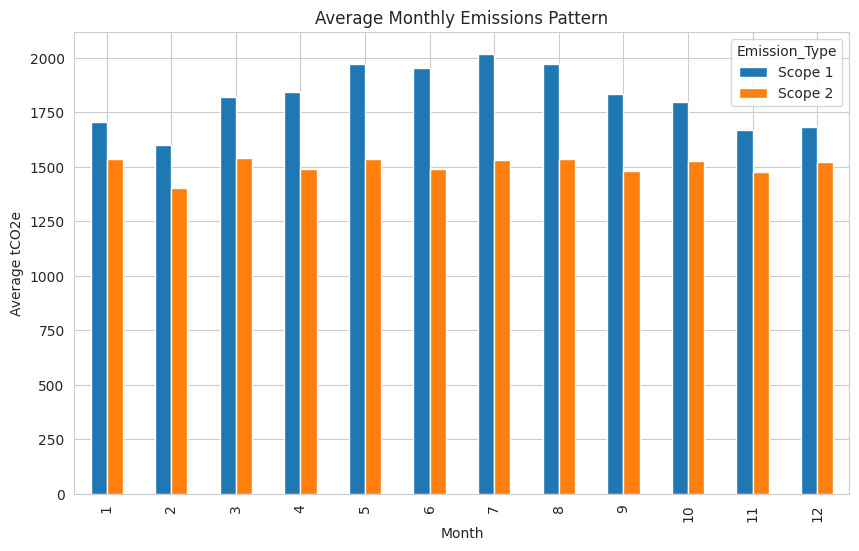

In [25]:
# Monthly Seasonality Pattern
df["Month"] = df["YearMonth"].dt.month

monthly_avg = df.groupby("Month")[["Scope 1", "Scope 2"]].mean()

monthly_avg.plot(kind="bar", figsize=(10,6))
plt.title("Average Monthly Emissions Pattern")
plt.ylabel("Average tCO2e")
plt.savefig("Monthly_Emissions_Pattern.png", dpi=300, bbox_inches='tight' ) 
plt.show()


 This reveals recurring seasonal peaks (e.g., winter gas usage).

# Stationarity & Structural Changes

In [27]:
# Augmented Dickey-Fuller Test
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------------")

adf_test(scope1_series, "Scope 1")
adf_test(scope2_series, "Scope 2")


ADF Test for Scope 1
ADF Statistic: 2.426090355704914
p-value: 0.9990220637928775
----------------------------
ADF Test for Scope 2
ADF Statistic: -3.299451091941564
p-value: 0.014903028534300906
----------------------------


If p-value > 0.05 → Non-stationary

# Anomaly Detection

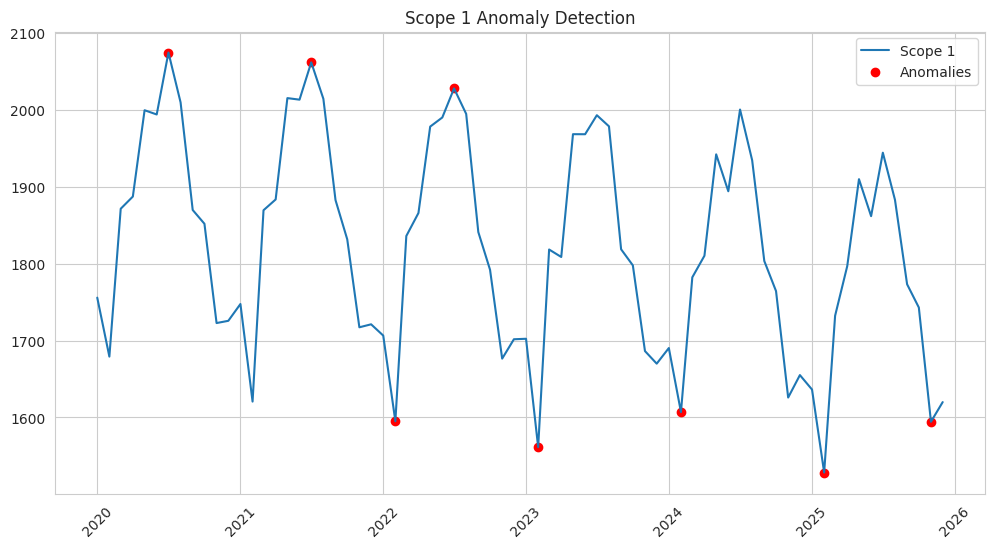

In [30]:
iso = IsolationForest(contamination=0.1, random_state=42)

df["Scope1_Anomaly"] = iso.fit_predict(df[["Scope 1"]].fillna(0))

plt.figure(figsize=(12,6))
plt.plot(df["YearMonth"], df["Scope 1"], label="Scope 1")
plt.scatter(
    df[df["Scope1_Anomaly"] == -1]["YearMonth"],
    df[df["Scope1_Anomaly"] == -1]["Scope 1"],
    color="red",
    label="Anomalies"
)

plt.legend()
plt.title("Scope 1 Anomaly Detection")
plt.xticks(rotation=45)
plt.savefig("Scope1_Anomaly_Detection.png", dpi=300, bbox_inches='tight' ) 
plt.show()


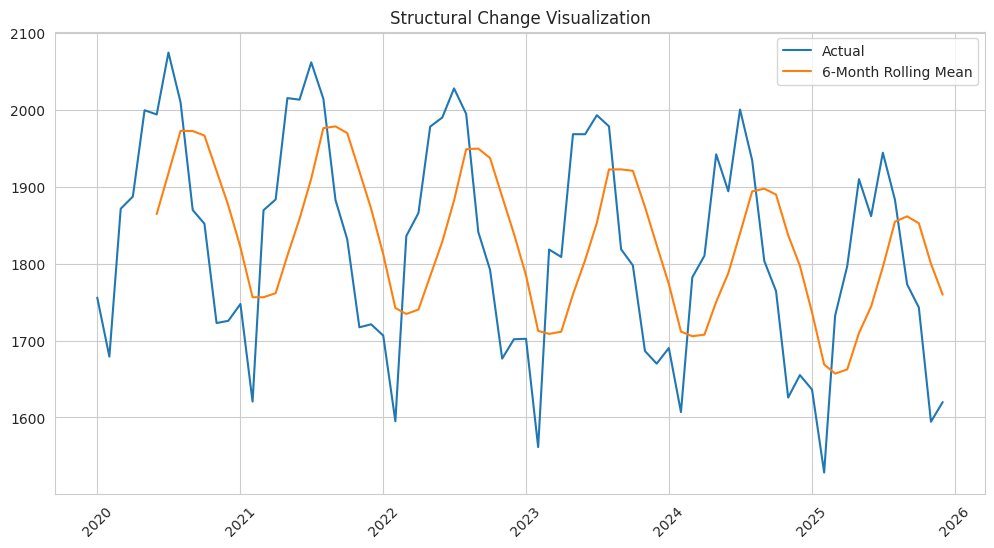

In [31]:
# Structural Breaks (Rolling Mean)
df["Scope1_RollingMean"] = df["Scope 1"].rolling(window=6).mean()

plt.figure(figsize=(12,6))
plt.plot(df["YearMonth"], df["Scope 1"], label="Actual")
plt.plot(df["YearMonth"], df["Scope1_RollingMean"], label="6-Month Rolling Mean")
plt.legend()
plt.title("Structural Change Visualization")
plt.xticks(rotation=45)
plt.savefig("Structural_Change.png", dpi=300, bbox_inches='tight' ) 
plt.show()


Large shifts in rolling mean may indicate structural changes.

# Scope Contribution Analysis

In [32]:
# Percentage Contribution
df["Scope1_%"] = df["Scope 1"] / df["Total_Emissions"] * 100
df["Scope2_%"] = df["Scope 2"] / df["Total_Emissions"] * 100

df[["YearMonth", "Scope1_%", "Scope2_%"]].head()


Emission_Type,YearMonth,Scope1_%,Scope2_%
0,2020-01-01,47.915220,52.084780
1,2020-02-01,48.361894,51.638106
2,2020-03-01,49.347510,50.652490
3,2020-04-01,50.217378,49.782622
4,2020-05-01,51.105064,48.894936


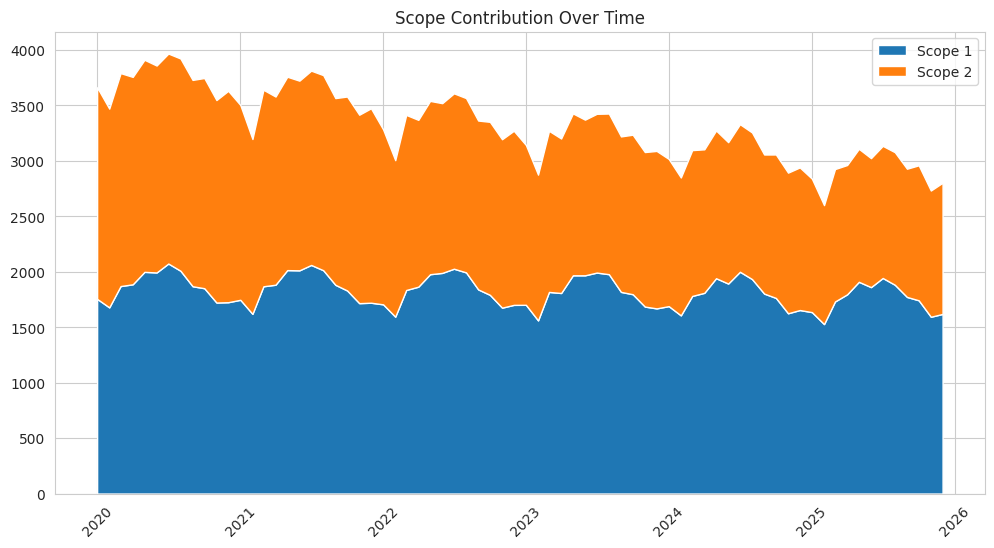

In [34]:
# Stacked Area Chart
plt.figure(figsize=(12,6))

plt.stackplot(
    df["YearMonth"],
    df["Scope 1"],
    df["Scope 2"],
    labels=["Scope 1", "Scope 2"]
)

plt.legend()
plt.title("Scope Contribution Over Time")
plt.xticks(rotation=45)
plt.savefig("Scope_Contribution_Over_Time.png", dpi=300, bbox_inches='tight' ) 
plt.show()
